<a href="https://colab.research.google.com/github/nasywafunnisa/pengolahan-citra-digital/blob/main/tugas_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


MEMUAT DATASET CIFAR-10
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training : (50000, 32, 32, 3)  |  Labels: (50000, 10)
Test     : (10000, 32, 32, 3)   |  Labels: (10000, 10)


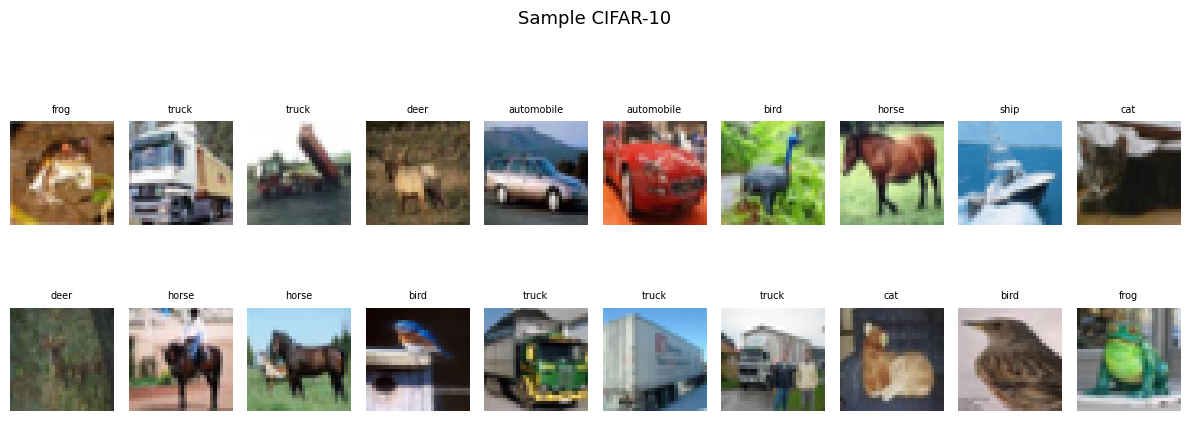


BAGIAN 1: CNN DARI AWAL (FROM SCRATCH)

[1b] Eksperimen variasi arsitektur & optimizer...

  → Adam lr=0.001 (baseline)
     Test Acc: 0.8642  |  Time: 263.6s

  → Adam lr=0.0001
     Test Acc: 0.8362  |  Time: 318.9s

  → SGD lr=0.01
     Test Acc: 0.8542  |  Time: 315.1s

  → Adam + Dropout=0.3
     Test Acc: 0.8591  |  Time: 300.6s


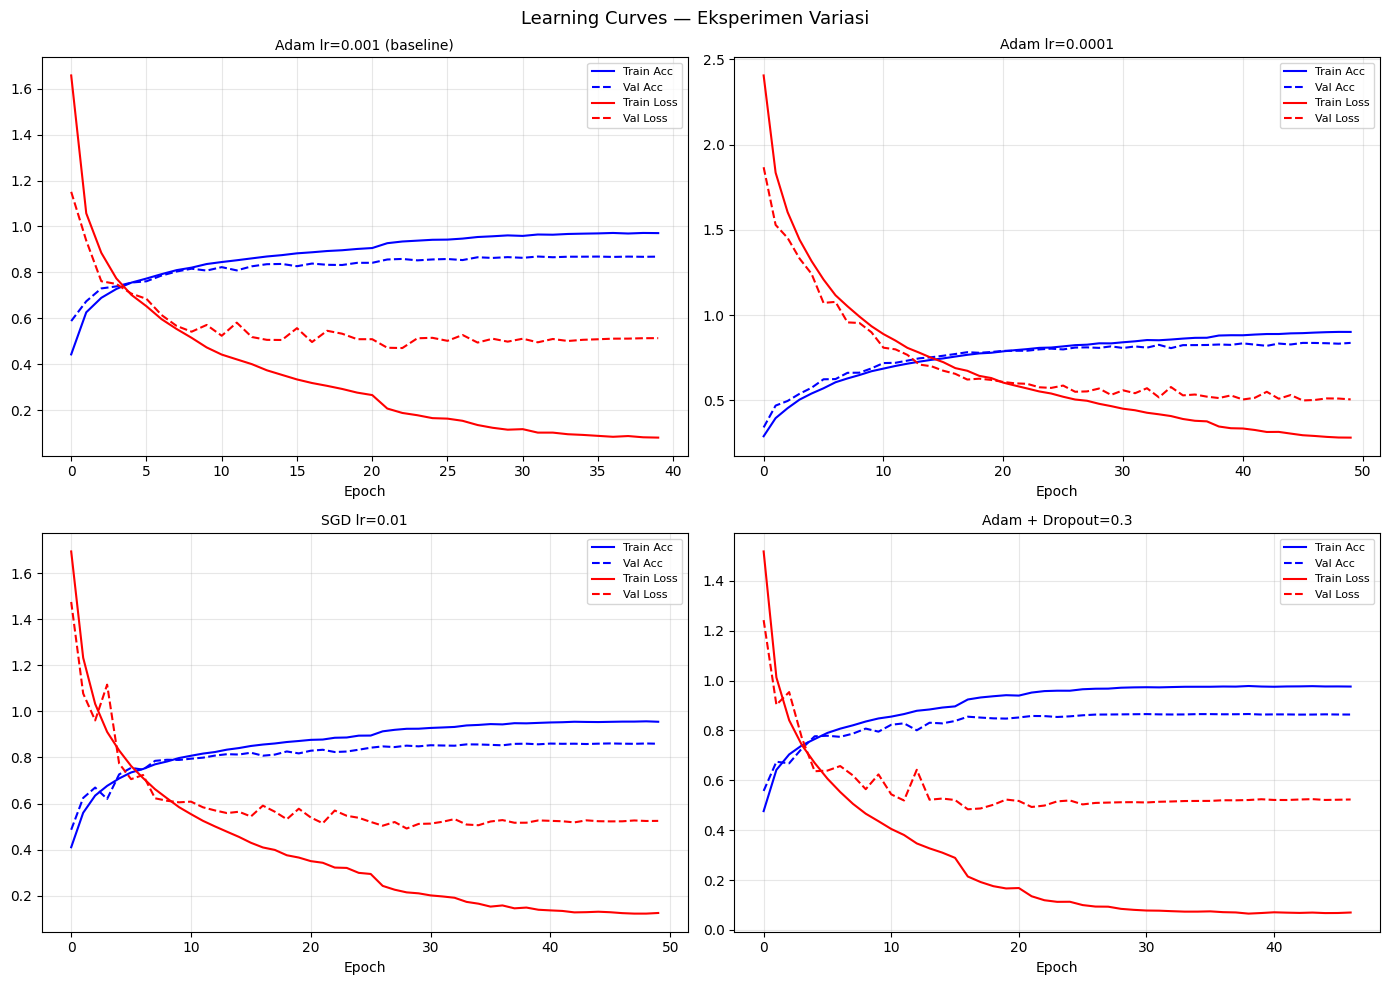


  ✓ Model terbaik: Adam lr=0.001 (baseline)  (acc=0.8642)

[1c] Visualisasi Feature Maps...


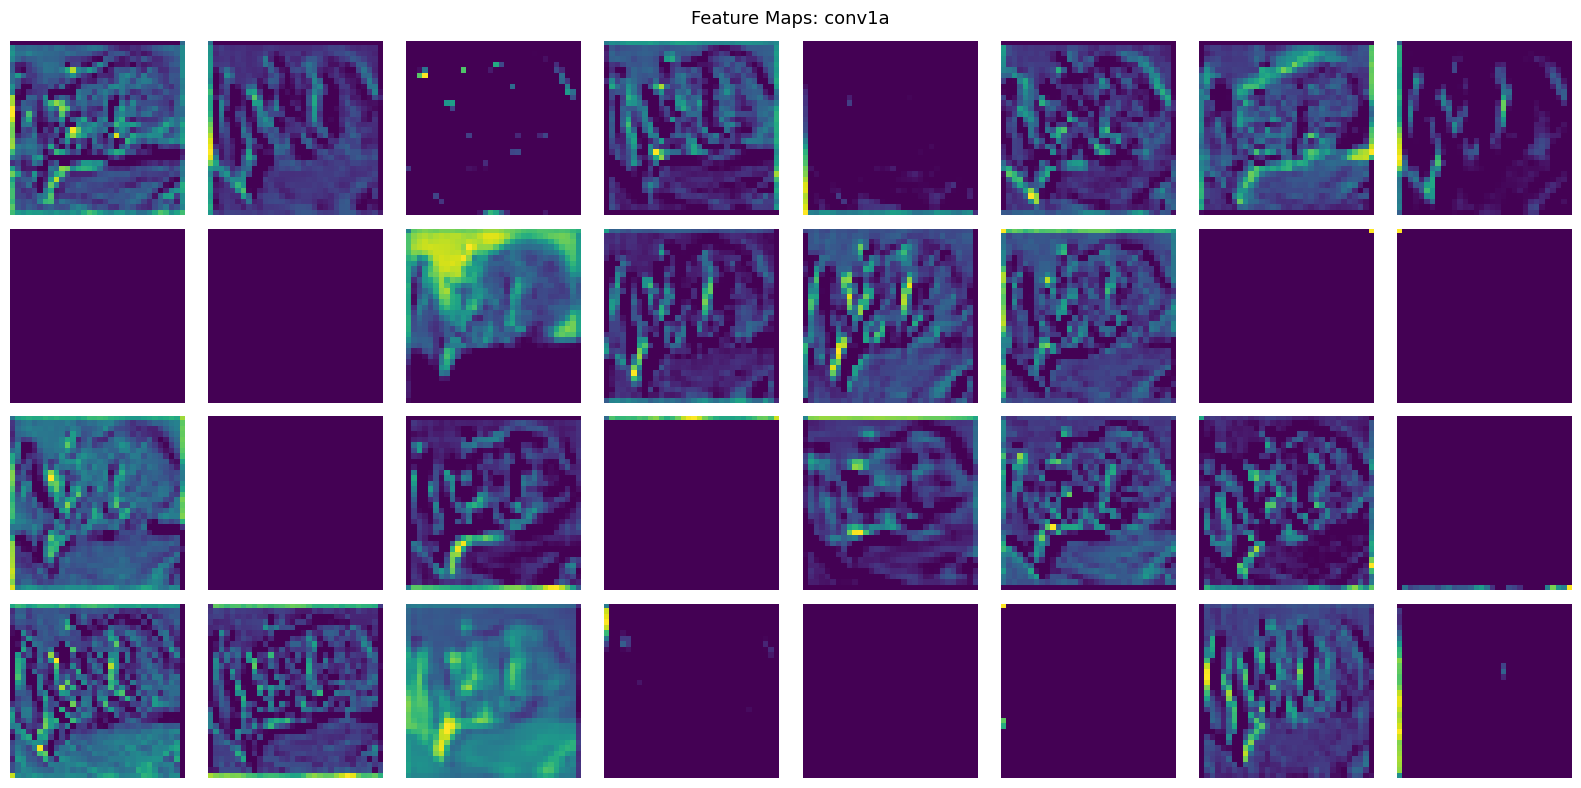


BAGIAN 2: DATA AUGMENTATION PIPELINE


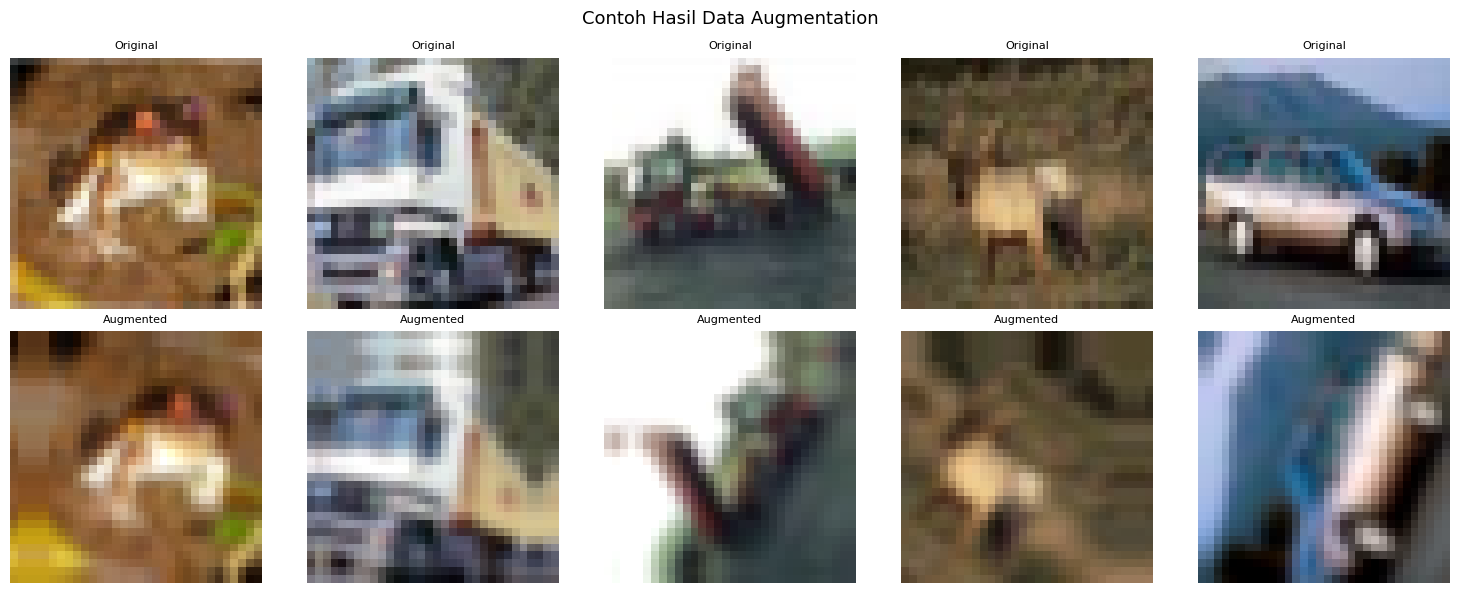


[2b] Training: tanpa augmentasi vs dengan augmentasi...
  → Tanpa augmentasi...
  → Dengan augmentasi...


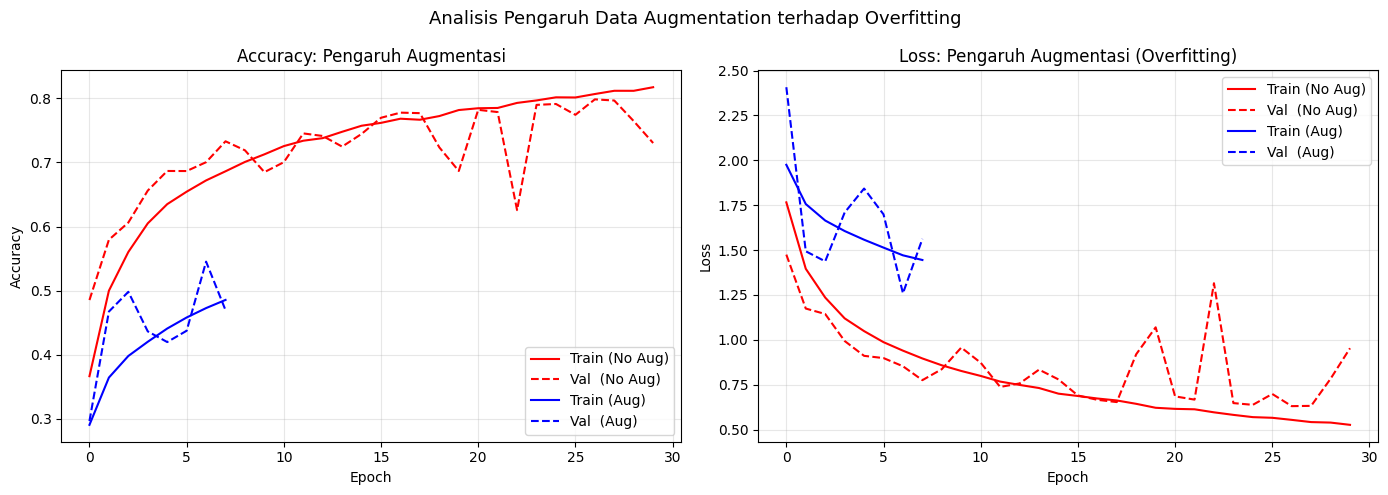


  Tanpa Augmentasi  → Test Acc: 0.7883
  Dengan Augmentasi → Test Acc: 0.3002

BAGIAN 3: TRANSFER LEARNING

  → Feature Extraction: VGG16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
     Test Acc: 0.1450  |  Time: 582.3s  |  Params: 14,849,610

  → Feature Extraction: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
     Test Acc: 0.3487  |  Time: 852.2s  |  Params: 24,115,850

  → Feature Extraction: MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
     Test Acc: 0.1000  |  Time: 167.6s  |  Params: 2,589,514

[3b] Fine-Tuning pada model terbaik: ResNet50
  Test Acc setelah Fine-Tuning: 0.5274


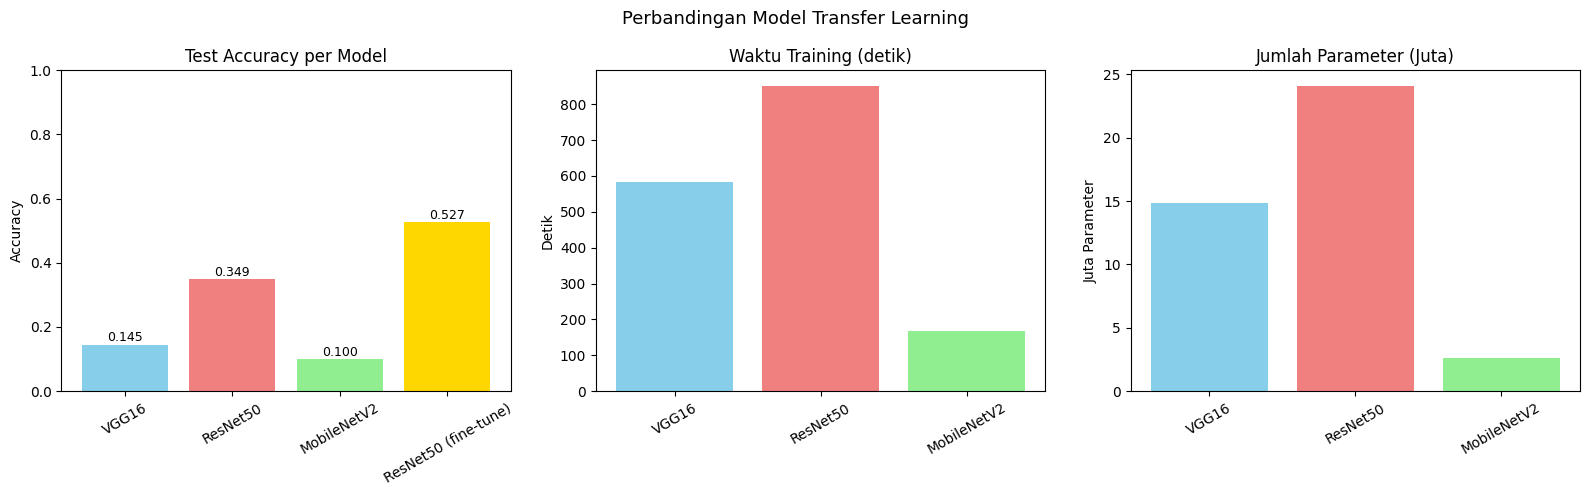


BAGIAN 4: EVALUASI KOMPREHENSIF

[4a] Classification Report (CNN Scratch):
              precision    recall  f1-score   support

    airplane       0.87      0.90      0.88      1000
  automobile       0.95      0.93      0.94      1000
        bird       0.83      0.76      0.79      1000
         cat       0.76      0.71      0.74      1000
        deer       0.84      0.86      0.85      1000
         dog       0.79      0.82      0.80      1000
        frog       0.87      0.91      0.89      1000
       horse       0.90      0.90      0.90      1000
        ship       0.93      0.92      0.92      1000
       truck       0.92      0.93      0.92      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



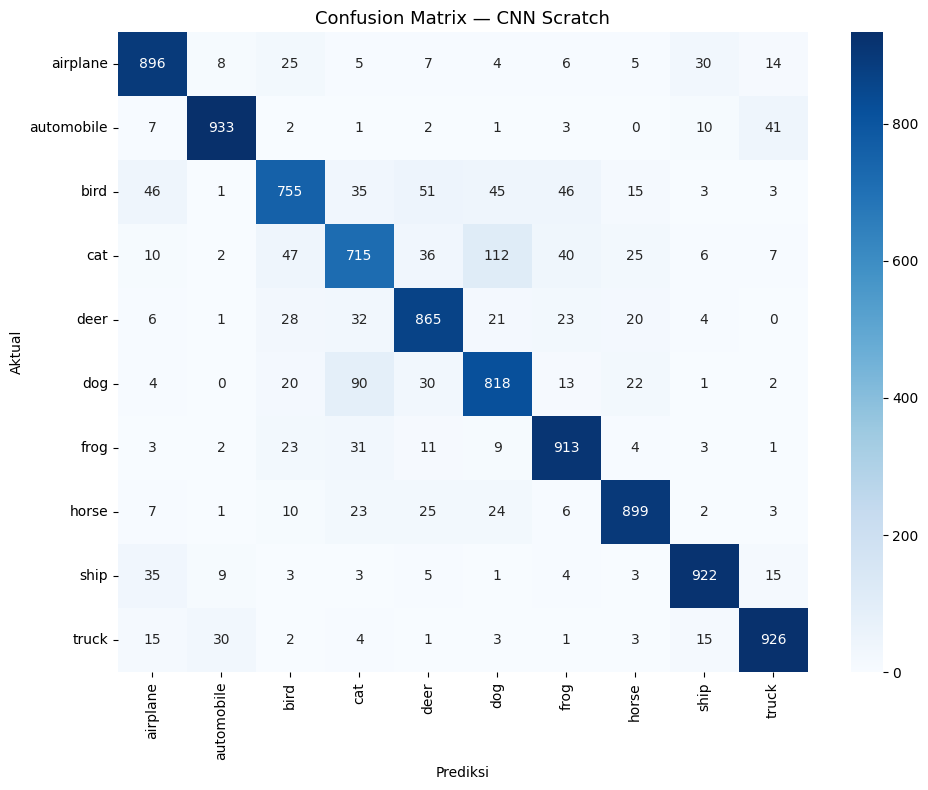

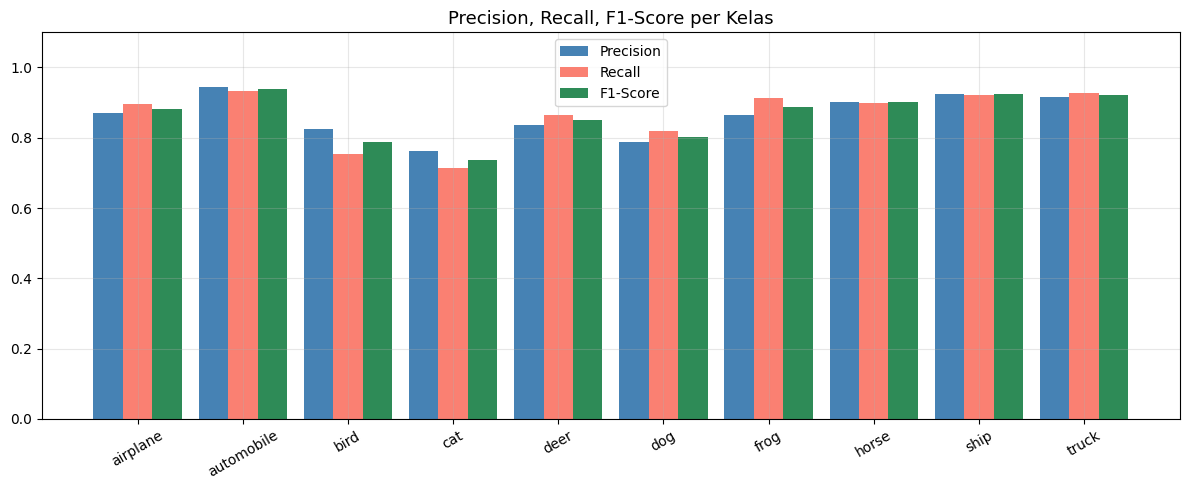

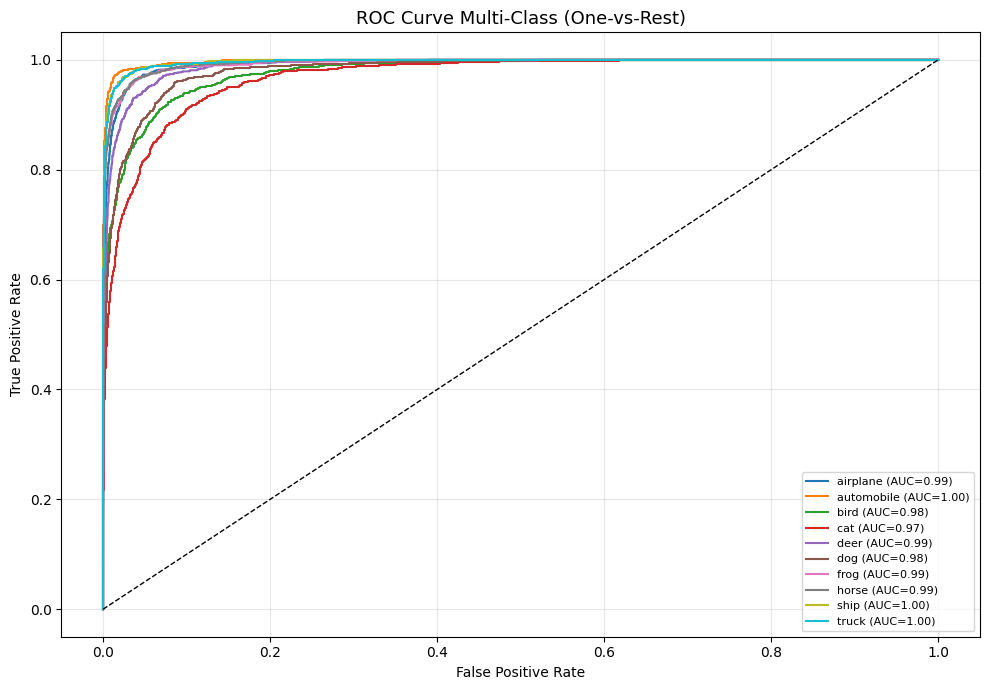


  Inference Time (scratch): 0.284 ms/gambar

BAGIAN 5: VISUALISASI & INTERPRETASI

[5a] Visualisasi Filter Conv Layer Pertama...


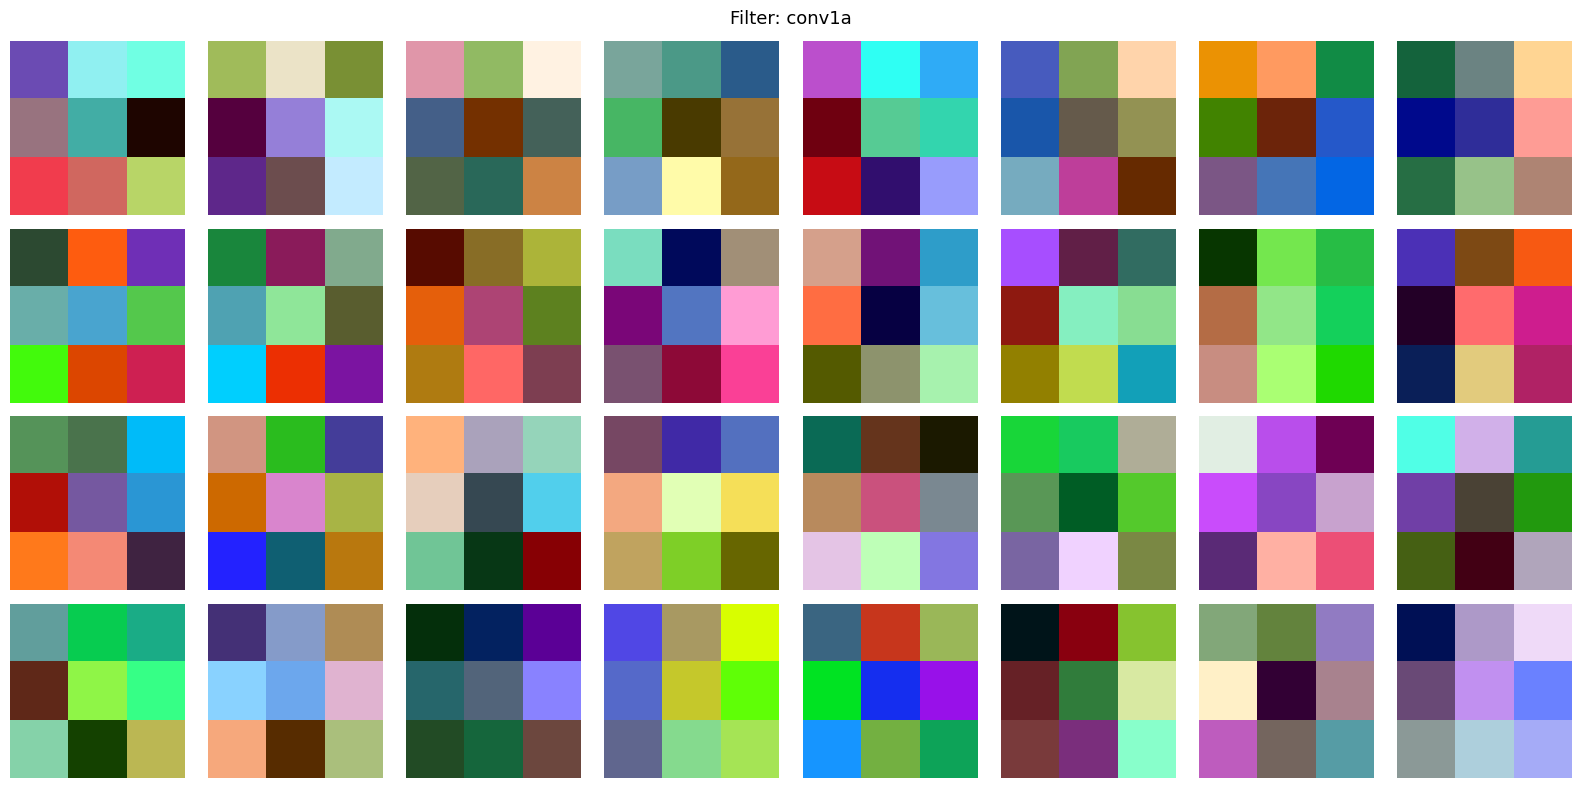


[5b] Grad-CAM...


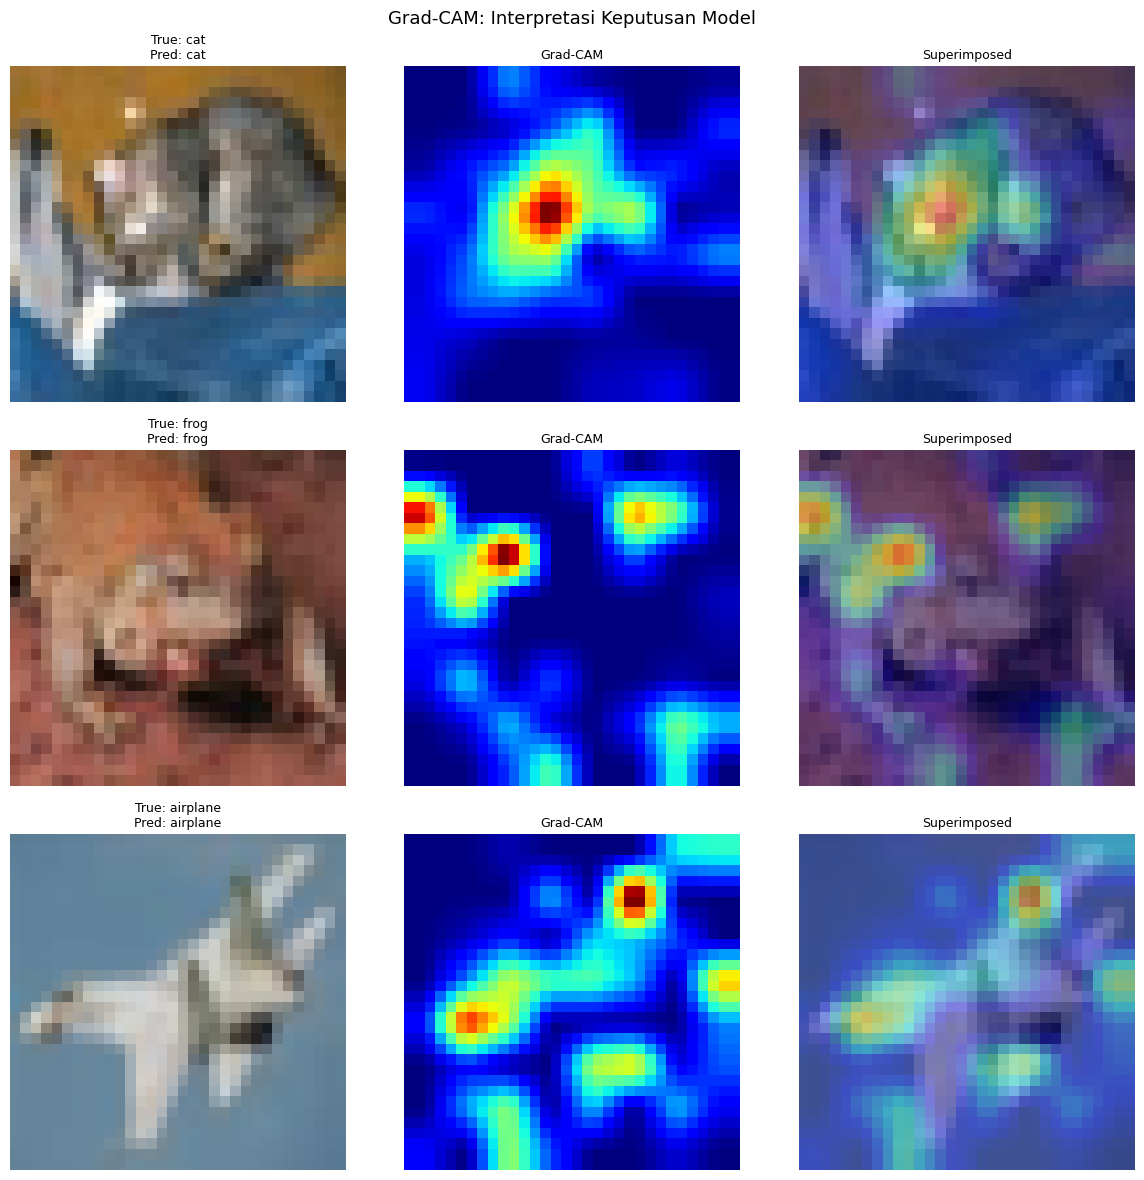


[5c] t-SNE & PCA Feature Embeddings...
  Menjalankan t-SNE...


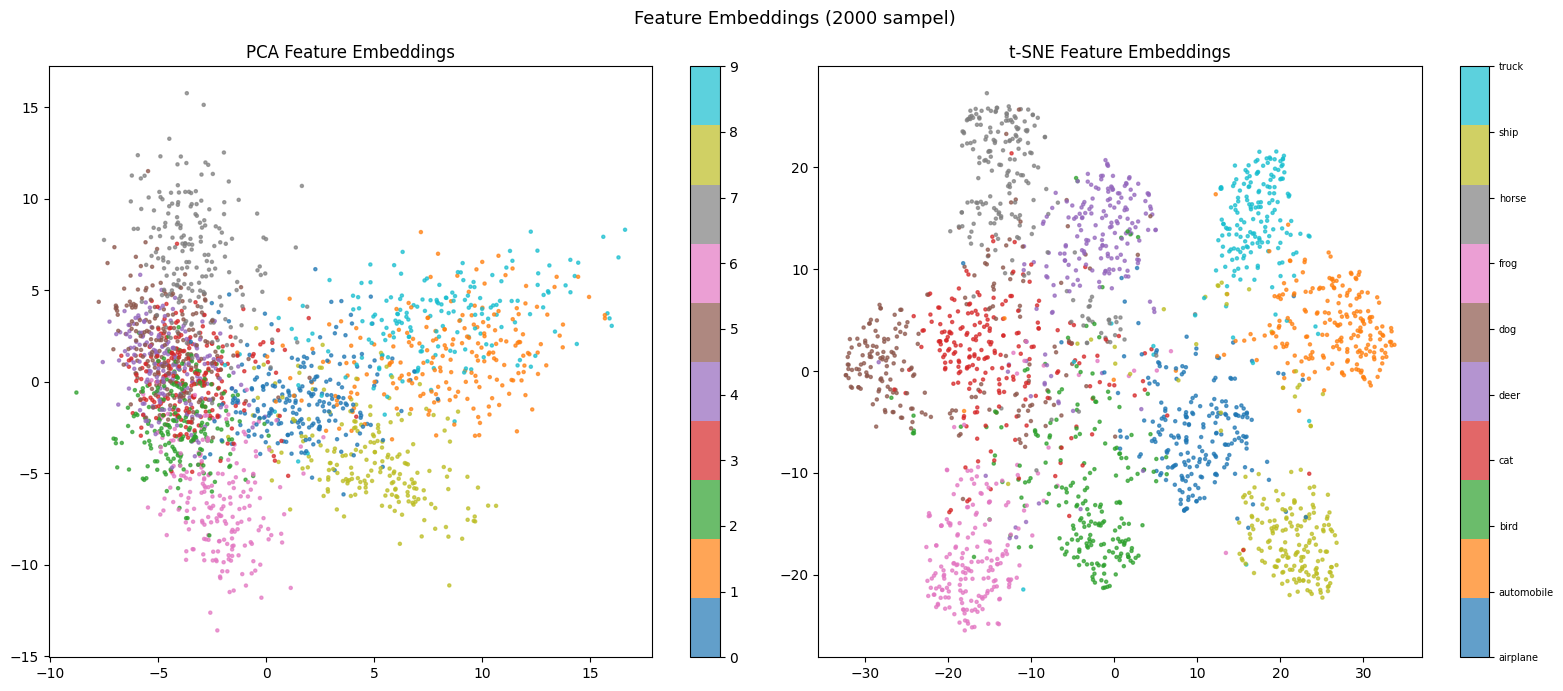


BAGIAN 6: ANALISIS & KESIMPULAN

{'Model':<30} {'Test Acc':>10} {'Waktu(s)':>10} {'Params':>12}
-----------------------------------------------------------------
  Scratch - Adam lr=0.001 (baseline)     0.8642      263.6             —
  Scratch - Adam lr=0.0001           0.8362      318.9             —
  Scratch - SGD lr=0.01              0.8542      315.1             —
  Scratch - Adam + Dropout=0.3       0.8591      300.6             —
  Augmentation                       0.3002            —             —
  TL-VGG16                           0.1450      582.3    14,849,610
  TL-ResNet50                        0.3487      852.2    24,115,850
  TL-MobileNetV2                     0.1000      167.6     2,589,514
  TL-ResNet50 (fine-tune)              0.5274            —             —


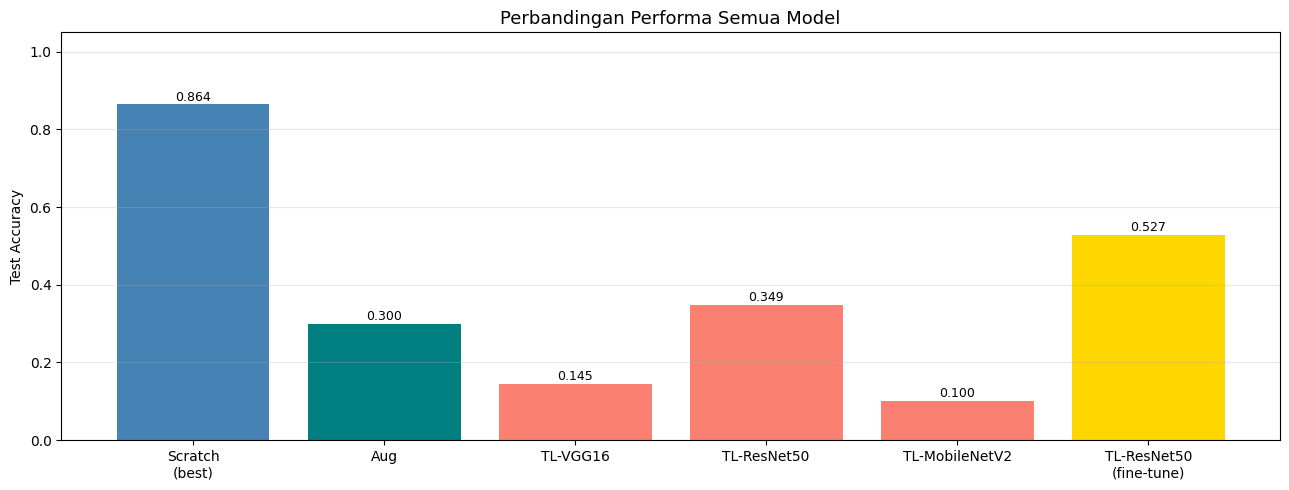


╔══════════════════════════════════════════════════════════╗
║              KESIMPULAN & REKOMENDASI                    ║
╠══════════════════════════════════════════════════════════╣
║  1. CNN Scratch                                          ║
║     • Hasil kompetitif tanpa pretrained weights          ║
║     • Butuh lebih banyak epoch & waktu training          ║
║     • Rentan overfitting tanpa augmentasi                ║
║                                                          ║
║  2. Strategi Fine-Tuning Optimal                         ║
║     • Feature extraction dulu (frozen base)              ║
║     • Lanjut fine-tune ~10 layer terakhir                ║
║     • Learning rate kecil (1e-5) saat fine-tune          ║
║                                                          ║
║  3. Augmentasi Paling Efektif                            ║
║     • RandomFlip + RandomRotation + RandomZoom           ║
║     • Mengurangi gap train-val (overfitting ↓)           ║
║                      

In [1]:
"""
=============================================================
TUGAS: Klasifikasi Citra dengan CNN
       Dari Awal hingga Transfer Learning
Dataset: CIFAR-10 (10 kelas, 60.000 gambar)
=============================================================
"""

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_recall_fscore_support,
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns

# ─────────────────────────────────────────────
# KONSTANTA GLOBAL
# ─────────────────────────────────────────────
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
NUM_CLASSES  = 10
IMG_SIZE     = 32
BATCH_SIZE   = 64
EPOCHS_SCRATCH = 50
EPOCHS_TRANSFER = 20
EPOCHS_FINETUNE = 10


# ══════════════════════════════════════════════════════════════
# BAGIAN 0 — LOAD & PERSIAPAN DATA
# ══════════════════════════════════════════════════════════════
def load_data():
    print("\n" + "="*60)
    print("MEMUAT DATASET CIFAR-10")
    print("="*60)

    (X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

    # Normalisasi
    X_train = X_train.astype('float32') / 255.0
    X_test  = X_test.astype('float32')  / 255.0

    # Label integer (untuk beberapa fungsi sklearn)
    y_train_int = y_train.flatten()
    y_test_int  = y_test.flatten()

    # One-hot
    y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
    y_test_oh  = keras.utils.to_categorical(y_test,  NUM_CLASSES)

    print(f"Training : {X_train.shape}  |  Labels: {y_train_oh.shape}")
    print(f"Test     : {X_test.shape}   |  Labels: {y_test_oh.shape}")

    # Visualisasi sampel
    plt.figure(figsize=(12, 5))
    for i in range(20):
        plt.subplot(2, 10, i + 1)
        plt.imshow(X_train[i])
        plt.title(CLASS_NAMES[y_train_int[i]], fontsize=7)
        plt.axis('off')
    plt.suptitle("Sample CIFAR-10", fontsize=13)
    plt.tight_layout()
    plt.show()

    return (X_train, y_train_int, y_train_oh), (X_test, y_test_int, y_test_oh)


# ══════════════════════════════════════════════════════════════
# BAGIAN 1 — CNN DARI AWAL (FROM SCRATCH)
# ══════════════════════════════════════════════════════════════
def bagian1_cnn_from_scratch(X_train, y_train_oh, X_test, y_test_oh, y_test_int):
    print("\n" + "="*60)
    print("BAGIAN 1: CNN DARI AWAL (FROM SCRATCH)")
    print("="*60)

    # ── 1a. Arsitektur Dasar ──────────────────────────────────
    def build_cnn(filters=(32,64,128), dense_units=256,
                  dropout=0.5, optimizer='adam', lr=0.001,
                  input_shape=(32,32,3)):
        model = keras.Sequential(name='CNN_Scratch')
        model.add(keras.Input(shape=input_shape))

        for i, f in enumerate(filters):
            model.add(layers.Conv2D(f, (3,3), padding='same', activation='relu',
                                    name=f'conv{i+1}a'))
            model.add(layers.BatchNormalization())
            model.add(layers.Conv2D(f, (3,3), padding='same', activation='relu',
                                    name=f'conv{i+1}b'))
            model.add(layers.BatchNormalization())
            model.add(layers.MaxPooling2D((2,2)))
            model.add(layers.Dropout(0.25))

        model.add(layers.Flatten())
        model.add(layers.Dense(dense_units, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout))
        model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

        if optimizer == 'adam':
            opt = keras.optimizers.Adam(learning_rate=lr)
        else:
            opt = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)

        model.compile(optimizer=opt,
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])
        return model

    # ── 1b. Eksperimen Variasi Arsitektur & Optimizer ─────────
    print("\n[1b] Eksperimen variasi arsitektur & optimizer...")

    experiments = [
        {'name': 'Adam lr=0.001 (baseline)', 'optimizer':'adam',  'lr':0.001, 'dropout':0.5},
        {'name': 'Adam lr=0.0001',            'optimizer':'adam',  'lr':0.0001,'dropout':0.5},
        {'name': 'SGD lr=0.01',               'optimizer':'sgd',   'lr':0.01,  'dropout':0.5},
        {'name': 'Adam + Dropout=0.3',        'optimizer':'adam',  'lr':0.001, 'dropout':0.3},
    ]

    exp_results  = {}
    exp_histories = {}

    for exp in experiments:
        print(f"\n  → {exp['name']}")
        m = build_cnn(optimizer=exp['optimizer'], lr=exp['lr'],
                      dropout=exp['dropout'])
        cb = [
            keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                          patience=8, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                              factor=0.5, patience=4, min_lr=1e-6)
        ]
        t0 = time.time()
        hist = m.fit(X_train, y_train_oh,
                     batch_size=BATCH_SIZE, epochs=EPOCHS_SCRATCH,
                     validation_split=0.2, callbacks=cb, verbose=0)
        train_time = time.time() - t0

        loss, acc = m.evaluate(X_test, y_test_oh, verbose=0)
        exp_results[exp['name']]   = {'acc': acc, 'loss': loss,
                                       'time': train_time, 'model': m}
        exp_histories[exp['name']] = hist
        print(f"     Test Acc: {acc:.4f}  |  Time: {train_time:.1f}s")

    # ── Plot learning curves semua eksperimen ─────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, (name, hist) in enumerate(exp_histories.items()):
        ax = axes[idx]
        ax.plot(hist.history['accuracy'],     label='Train Acc',  color='blue')
        ax.plot(hist.history['val_accuracy'], label='Val Acc',    color='blue',  linestyle='--')
        ax.plot(hist.history['loss'],         label='Train Loss', color='red')
        ax.plot(hist.history['val_loss'],     label='Val Loss',   color='red',   linestyle='--')
        ax.set_title(name, fontsize=10)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle("Learning Curves — Eksperimen Variasi", fontsize=13)
    plt.tight_layout()
    plt.show()

    # Pilih model terbaik
    best_name  = max(exp_results, key=lambda k: exp_results[k]['acc'])
    best_model = exp_results[best_name]['model']
    print(f"\n  ✓ Model terbaik: {best_name}  (acc={exp_results[best_name]['acc']:.4f})")

    # ── 1c. Feature Maps ──────────────────────────────────────
    print("\n[1c] Visualisasi Feature Maps...")

    inp   = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x     = inp
    feat_outputs = []
    feat_names   = []
    for layer in best_model.layers:
        x = layer(x)
        if 'conv' in layer.name and layer.name.endswith('a'):
            feat_outputs.append(x)
            feat_names.append(layer.name)

    feat_model = keras.Model(inputs=inp, outputs=feat_outputs)
    sample_img = X_test[0:1]
    activations = feat_model.predict(sample_img, verbose=0)

    for fname, act in zip(feat_names, activations[:1]):   # hanya conv layer pertama
        n_feat = min(act.shape[-1], 32)
        n_cols = 8
        n_rows = n_feat // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2))
        fig.suptitle(f'Feature Maps: {fname}', fontsize=13)
        for i in range(n_feat):
            ax = axes[i // n_cols, i % n_cols]
            ax.imshow(act[0, :, :, i], cmap='viridis')
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    return best_model, exp_results, exp_histories[best_name]


# ══════════════════════════════════════════════════════════════
# BAGIAN 2 — DATA AUGMENTATION
# ══════════════════════════════════════════════════════════════
def bagian2_data_augmentation(X_train, y_train_oh, X_test, y_test_oh):
    print("\n" + "="*60)
    print("BAGIAN 2: DATA AUGMENTATION PIPELINE")
    print("="*60)

    # ── 2a. Visualisasi augmentasi ────────────────────────────
    aug_pipeline = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
        layers.RandomContrast(0.2),
        layers.RandomTranslation(0.1, 0.1),
    ], name='augmentation')

    plt.figure(figsize=(15, 6))
    for i in range(5):
        plt.subplot(2, 5, i + 1)
        plt.imshow(X_train[i])
        plt.title("Original", fontsize=8)
        plt.axis('off')

        plt.subplot(2, 5, i + 6)
        aug = aug_pipeline(tf.expand_dims(X_train[i], 0), training=True)
        plt.imshow(np.clip(aug[0].numpy(), 0, 1))
        plt.title("Augmented", fontsize=8)
        plt.axis('off')

    plt.suptitle("Contoh Hasil Data Augmentation", fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── 2b. Bandingkan: tanpa vs dengan augmentasi ────────────
    print("\n[2b] Training: tanpa augmentasi vs dengan augmentasi...")

    def build_aug_model(use_aug=False):
        inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
        x   = inp
        if use_aug:
            x = layers.RandomFlip("horizontal")(x)
            x = layers.RandomRotation(0.2)(x)
            x = layers.RandomZoom(0.2)(x)
            x = layers.RandomContrast(0.2)(x)
        for f in [32, 64, 128]:
            x = layers.Conv2D(f, (3,3), padding='same', activation='relu')(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling2D()(x)
            x = layers.Dropout(0.25)(x)
        x = layers.Flatten()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
        m = keras.Model(inp, out)
        m.compile(optimizer='adam', loss='categorical_crossentropy',
                  metrics=['accuracy'])
        return m

    cb = [keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                         patience=8, restore_best_weights=True)]

    EPOCHS_AUG = 30

    print("  → Tanpa augmentasi...")
    m_no  = build_aug_model(use_aug=False)
    h_no  = m_no.fit(X_train, y_train_oh, batch_size=BATCH_SIZE,
                     epochs=EPOCHS_AUG, validation_split=0.2,
                     callbacks=cb, verbose=0)

    print("  → Dengan augmentasi...")
    m_aug = build_aug_model(use_aug=True)
    h_aug = m_aug.fit(X_train, y_train_oh, batch_size=BATCH_SIZE,
                      epochs=EPOCHS_AUG, validation_split=0.2,
                      callbacks=cb, verbose=0)

    # Plot perbandingan
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(h_no.history['accuracy'],      label='Train (No Aug)',  color='red')
    ax1.plot(h_no.history['val_accuracy'],  label='Val  (No Aug)',   color='red',  linestyle='--')
    ax1.plot(h_aug.history['accuracy'],     label='Train (Aug)',     color='blue')
    ax1.plot(h_aug.history['val_accuracy'], label='Val  (Aug)',      color='blue', linestyle='--')
    ax1.set_title('Accuracy: Pengaruh Augmentasi')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(h_no.history['loss'],      label='Train (No Aug)',  color='red')
    ax2.plot(h_no.history['val_loss'],  label='Val  (No Aug)',   color='red',  linestyle='--')
    ax2.plot(h_aug.history['loss'],     label='Train (Aug)',     color='blue')
    ax2.plot(h_aug.history['val_loss'], label='Val  (Aug)',      color='blue', linestyle='--')
    ax2.set_title('Loss: Pengaruh Augmentasi (Overfitting)')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.suptitle("Analisis Pengaruh Data Augmentation terhadap Overfitting", fontsize=13)
    plt.tight_layout()
    plt.show()

    _, acc_no  = m_no.evaluate(X_test, y_test_oh, verbose=0)
    _, acc_aug = m_aug.evaluate(X_test, y_test_oh, verbose=0)
    print(f"\n  Tanpa Augmentasi  → Test Acc: {acc_no:.4f}")
    print(f"  Dengan Augmentasi → Test Acc: {acc_aug:.4f}")

    return m_aug


# ══════════════════════════════════════════════════════════════
# BAGIAN 3 — TRANSFER LEARNING
# ══════════════════════════════════════════════════════════════
def bagian3_transfer_learning(X_train, y_train_oh, X_test, y_test_oh):
    print("\n" + "="*60)
    print("BAGIAN 3: TRANSFER LEARNING")
    print("="*60)

    # CIFAR-10 perlu di-resize ke 224x224 untuk VGG/ResNet
    # Gunakan tf.data pipeline dengan resize on-the-fly
    IMG_TL = 96   # ukuran kompromi (lebih cepat dari 224)

    def make_dataset(X, y, augment=False, shuffle=True):
        ds = tf.data.Dataset.from_tensor_slices((X, y))
        if shuffle:
            ds = ds.shuffle(len(X))

        def preprocess(img, label):
            img = tf.image.resize(img, [IMG_TL, IMG_TL])
            if augment:
                img = tf.image.random_flip_left_right(img)
                img = tf.image.random_brightness(img, 0.1)
                img = tf.image.random_contrast(img, 0.9, 1.1)
            return img, label

        return ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)\
                 .batch(32).prefetch(tf.data.AUTOTUNE)

    ds_train = make_dataset(X_train, y_train_oh, augment=True)
    ds_val   = make_dataset(X_train[-10000:], y_train_oh[-10000:],
                            augment=False, shuffle=False)
    ds_test  = make_dataset(X_test,  y_test_oh,  augment=False, shuffle=False)

    # ── 3a. Feature Extraction ────────────────────────────────
    def build_transfer(base_fn, preprocess_fn, name,
                       input_shape=(IMG_TL, IMG_TL, 3), trainable=False):
        base = base_fn(weights='imagenet', include_top=False,
                       input_shape=input_shape)
        base.trainable = trainable

        inp = keras.Input(shape=input_shape)
        x   = preprocess_fn(inp)
        x   = base(x, training=False)
        x   = layers.GlobalAveragePooling2D()(x)
        x   = layers.Dense(256, activation='relu')(x)
        x   = layers.BatchNormalization()(x)
        x   = layers.Dropout(0.5)(x)
        out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

        model = keras.Model(inp, out, name=name)
        model.compile(optimizer=keras.optimizers.Adam(1e-3),
                      loss='categorical_crossentropy', metrics=['accuracy'])
        return model, base

    models_cfg = {
        'VGG16': (keras.applications.VGG16,
                  keras.applications.vgg16.preprocess_input),
        'ResNet50': (keras.applications.ResNet50,
                     keras.applications.resnet.preprocess_input),
        'MobileNetV2': (keras.applications.MobileNetV2,
                        keras.applications.mobilenet_v2.preprocess_input),
    }

    tl_results = {}
    cb_tl = [keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                            patience=5, restore_best_weights=True)]

    for mname, (fn, prep) in models_cfg.items():
        print(f"\n  → Feature Extraction: {mname}")
        try:
            model, base = build_transfer(fn, prep, mname)
            t0   = time.time()
            hist = model.fit(ds_train, validation_data=ds_val,
                             epochs=EPOCHS_TRANSFER, callbacks=cb_tl, verbose=0)
            train_time = time.time() - t0
            _, acc = model.evaluate(ds_test, verbose=0)
            tl_results[mname] = {
                'acc': acc, 'time': train_time,
                'params': model.count_params(),
                'model': model, 'base': base,
                'prep': prep, 'fn': fn
            }
            print(f"     Test Acc: {acc:.4f}  |  Time: {train_time:.1f}s"
                  f"  |  Params: {model.count_params():,}")
        except Exception as e:
            print(f"     ERROR: {e}")

    # ── 3b. Fine-Tuning (model terbaik) ───────────────────────
    best_tl = max(tl_results, key=lambda k: tl_results[k]['acc'])
    print(f"\n[3b] Fine-Tuning pada model terbaik: {best_tl}")

    ft_model, ft_base = build_transfer(
        tl_results[best_tl]['fn'],
        tl_results[best_tl]['prep'],
        f"{best_tl}_finetune"
    )

    # Tahap 1 – Feature Extraction
    ft_model.fit(ds_train, validation_data=ds_val,
                 epochs=EPOCHS_TRANSFER, callbacks=cb_tl, verbose=0)

    # Tahap 2 – Fine-Tune layer terakhir
    ft_base.trainable = True
    fine_tune_at = len(ft_base.layers) - 10
    for layer in ft_base.layers[:fine_tune_at]:
        layer.trainable = False

    ft_model.compile(optimizer=keras.optimizers.Adam(1e-5),
                     loss='categorical_crossentropy', metrics=['accuracy'])

    hist_ft = ft_model.fit(ds_train, validation_data=ds_val,
                           epochs=EPOCHS_FINETUNE, callbacks=cb_tl, verbose=0)

    _, acc_ft = ft_model.evaluate(ds_test, verbose=0)
    print(f"  Test Acc setelah Fine-Tuning: {acc_ft:.4f}")

    # ── 3c. Plot perbandingan semua model TL ──────────────────
    names   = list(tl_results.keys()) + [f'{best_tl} (fine-tune)']
    accs    = [tl_results[k]['acc'] for k in tl_results] + [acc_ft]
    times   = [tl_results[k]['time'] for k in tl_results] + [0]
    params  = [tl_results[k]['params']/1e6 for k in tl_results] + [0]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    bars = axes[0].bar(names, accs,
                       color=['skyblue','lightcoral','lightgreen','gold'])
    axes[0].set_title('Test Accuracy per Model')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis='x', rotation=30)
    for b, a in zip(bars, accs):
        axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                     f'{a:.3f}', ha='center', fontsize=9)

    axes[1].bar(names[:-1], times[:-1],
                color=['skyblue','lightcoral','lightgreen'])
    axes[1].set_title('Waktu Training (detik)')
    axes[1].set_ylabel('Detik')
    axes[1].tick_params(axis='x', rotation=30)

    axes[2].bar(names[:-1], params[:-1],
                color=['skyblue','lightcoral','lightgreen'])
    axes[2].set_title('Jumlah Parameter (Juta)')
    axes[2].set_ylabel('Juta Parameter')
    axes[2].tick_params(axis='x', rotation=30)

    plt.suptitle("Perbandingan Model Transfer Learning", fontsize=13)
    plt.tight_layout()
    plt.show()

    return ft_model, tl_results, acc_ft


# ══════════════════════════════════════════════════════════════
# BAGIAN 4 — EVALUASI KOMPREHENSIF
# ══════════════════════════════════════════════════════════════
def bagian4_evaluasi(model_scratch, model_tl, X_test, y_test_int, y_test_oh):
    print("\n" + "="*60)
    print("BAGIAN 4: EVALUASI KOMPREHENSIF")
    print("="*60)

    # Prediksi model scratch
    t0 = time.time()
    y_pred_prob = model_scratch.predict(X_test, verbose=0)
    inf_time_scratch = (time.time() - t0) / len(X_test) * 1000  # ms/img

    y_pred = np.argmax(y_pred_prob, axis=1)

    # ── 4a. Classification Report ─────────────────────────────
    print("\n[4a] Classification Report (CNN Scratch):")
    print(classification_report(y_test_int, y_pred, target_names=CLASS_NAMES))

    # ── 4b. Confusion Matrix ──────────────────────────────────
    cm = confusion_matrix(y_test_int, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Confusion Matrix — CNN Scratch', fontsize=13)
    plt.xlabel('Prediksi'); plt.ylabel('Aktual')
    plt.tight_layout()
    plt.show()

    # ── 4c. Per-class Precision / Recall / F1 ─────────────────
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test_int, y_pred, average=None
    )

    x = np.arange(NUM_CLASSES)
    width = 0.28
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width, prec, width, label='Precision', color='steelblue')
    ax.bar(x,          rec,  width, label='Recall',    color='salmon')
    ax.bar(x + width,  f1,   width, label='F1-Score',  color='seagreen')
    ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=30)
    ax.set_ylim(0, 1.1); ax.legend()
    ax.set_title('Precision, Recall, F1-Score per Kelas', fontsize=13)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ── 4d. ROC Curve Multi-Class (OvR) ───────────────────────
    y_bin = label_binarize(y_test_int, classes=list(range(NUM_CLASSES)))

    plt.figure(figsize=(10, 7))
    colors = plt.cm.get_cmap('tab10', NUM_CLASSES)

    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_pred_prob[:, i])
        roc_auc     = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors(i), lw=1.5,
                 label=f'{CLASS_NAMES[i]} (AUC={roc_auc:.2f})')

    plt.plot([0,1],[0,1],'k--', lw=1)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Multi-Class (One-vs-Rest)', fontsize=13)
    plt.legend(loc='lower right', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n  Inference Time (scratch): {inf_time_scratch:.3f} ms/gambar")

    return y_pred_prob, y_pred


def bagian5_visualisasi(model, X_test, y_test_int, y_pred_prob):
    print("\n" + "="*60)
    print("BAGIAN 5: VISUALISASI & INTERPRETASI")
    print("="*60)

    # ── Bangun ulang model secara eksplisit ──────────────────
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = inp
    conv_outputs = []
    conv_names   = []
    embed_output = None

    for i, layer in enumerate(model.layers):
        x = layer(x)
        if isinstance(layer, layers.Conv2D):
            conv_outputs.append(x)
            conv_names.append(layer.name)
        # Output sebelum Dense terakhir (layer ke -2 dari belakang)
        if i == len(model.layers) - 3:
            embed_output = x

    # ── 5a. Filter Visualization ──────────────────────────────
    print("\n[5a] Visualisasi Filter Conv Layer Pertama...")
    first_conv = None
    for layer in model.layers:
        if isinstance(layer, layers.Conv2D):
            first_conv = layer
            break

    if first_conv is not None:
        weights = first_conv.get_weights()[0]
        n_filt  = min(weights.shape[-1], 32)
        n_cols  = 8
        n_rows  = n_filt // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2))
        fig.suptitle(f'Filter: {first_conv.name}', fontsize=13)
        for i in range(n_filt):
            ax = axes[i // n_cols, i % n_cols]
            filt = weights[:, :, :, i]
            filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)
            ax.imshow(filt)
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    # ── 5b. Grad-CAM ──────────────────────────────────────────
    print("\n[5b] Grad-CAM...")

    if len(conv_outputs) > 0:
        grad_model = keras.Model(inputs=inp,
                                 outputs=[conv_outputs[-1], x])  # last conv + output

        def get_gradcam(img_array, class_idx):
            with tf.GradientTape() as tape:
                conv_out, preds = grad_model(img_array)
                loss = preds[:, class_idx]
            grads    = tape.gradient(loss, conv_out)
            pooled   = tf.reduce_mean(grads, axis=(0, 1, 2))
            heatmap  = conv_out[0] @ pooled[..., tf.newaxis]
            heatmap  = tf.squeeze(heatmap)
            heatmap  = tf.maximum(heatmap, 0)
            heatmap  = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
            return heatmap.numpy()

        fig, axes = plt.subplots(3, 3, figsize=(12, 12))
        for row, idx in enumerate([0, 5, 10]):
            img  = X_test[idx:idx+1]
            true = y_test_int[idx]
            pred = np.argmax(y_pred_prob[idx])

            heatmap = get_gradcam(img, pred)
            heatmap_resized = np.array(
                tf.image.resize(heatmap[..., np.newaxis],
                                [IMG_SIZE, IMG_SIZE])
            ).squeeze()

            # Original
            axes[row, 0].imshow(X_test[idx])
            axes[row, 0].set_title(
                f'True: {CLASS_NAMES[true]}\nPred: {CLASS_NAMES[pred]}',
                fontsize=9)
            axes[row, 0].axis('off')

            # Heatmap
            axes[row, 1].imshow(heatmap_resized, cmap='jet')
            axes[row, 1].set_title('Grad-CAM', fontsize=9)
            axes[row, 1].axis('off')

            # Superimposed
            heatmap_colored = cm.jet(heatmap_resized)[:, :, :3]
            superimposed    = np.clip(
                0.4 * heatmap_colored + 0.6 * X_test[idx], 0, 1)
            axes[row, 2].imshow(superimposed)
            axes[row, 2].set_title('Superimposed', fontsize=9)
            axes[row, 2].axis('off')

        plt.suptitle("Grad-CAM: Interpretasi Keputusan Model", fontsize=13)
        plt.tight_layout()
        plt.show()

    # ── 5c. t-SNE & PCA ──────────────────────────────────────
    print("\n[5c] t-SNE & PCA Feature Embeddings...")

    if embed_output is not None:
        embed_model = keras.Model(inputs=inp, outputs=embed_output)
        N_SAMPLE    = 2000
        idx_s       = np.random.choice(len(X_test), N_SAMPLE, replace=False)
        embeds      = embed_model.predict(X_test[idx_s], batch_size=128, verbose=0)
        labels_s    = y_test_int[idx_s]

        pca50        = PCA(n_components=min(50, embeds.shape[1]))
        embeds_pca50 = pca50.fit_transform(embeds)

        print("  Menjalankan t-SNE...")
        tsne      = TSNE(n_components=2, random_state=42,
                         perplexity=30, n_iter=500)
        embeds_2d = tsne.fit_transform(embeds_pca50)

        pca2          = PCA(n_components=2)
        embeds_2d_pca = pca2.fit_transform(embeds)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

        sc1 = ax1.scatter(embeds_2d_pca[:, 0], embeds_2d_pca[:, 1],
                          c=labels_s, cmap='tab10', s=5, alpha=0.7)
        ax1.set_title('PCA Feature Embeddings', fontsize=12)
        plt.colorbar(sc1, ax=ax1, ticks=range(NUM_CLASSES))

        sc2 = ax2.scatter(embeds_2d[:, 0], embeds_2d[:, 1],
                          c=labels_s, cmap='tab10', s=5, alpha=0.7)
        ax2.set_title('t-SNE Feature Embeddings', fontsize=12)
        cbar = plt.colorbar(sc2, ax=ax2, ticks=range(NUM_CLASSES))
        cbar.ax.set_yticklabels(CLASS_NAMES, fontsize=7)

        plt.suptitle("Feature Embeddings (2000 sampel)", fontsize=13)
        plt.tight_layout()
        plt.show()


# ══════════════════════════════════════════════════════════════
# BAGIAN 6 — ANALISIS & KESIMPULAN
# ══════════════════════════════════════════════════════════════
def bagian6_analisis(exp_results, tl_results, acc_ft_finetune, acc_aug):
    print("\n" + "="*60)
    print("BAGIAN 6: ANALISIS & KESIMPULAN")
    print("="*60)

    # ── Tabel perbandingan semua model ────────────────────────
    print("\n{'Model':<30} {'Test Acc':>10} {'Waktu(s)':>10} {'Params':>12}")
    print("-" * 65)

    for name, res in exp_results.items():
        print(f"  Scratch - {name:<20} {res['acc']:>10.4f}"
              f" {res['time']:>10.1f}  {'—':>12}")

    print(f"  {'Augmentation':30} {acc_aug:>10.4f}   {'—':>10}  {'—':>12}")

    for name, res in tl_results.items():
        print(f"  TL-{name:<27} {res['acc']:>10.4f}"
              f" {res['time']:>10.1f}  {res['params']:>12,}")

    best_tl = max(tl_results, key=lambda k: tl_results[k]['acc'])
    print(f"  TL-{best_tl} (fine-tune)          {acc_ft_finetune:>10.4f}"
          f"   {'—':>10}  {'—':>12}")

    # ── Bar Chart Ringkasan ───────────────────────────────────
    all_names = (
        ['Scratch\n(best)'] +
        ['Aug'] +
        [f'TL-{k}' for k in tl_results] +
        [f'TL-{best_tl}\n(fine-tune)']
    )
    best_scratch_acc = max(r['acc'] for r in exp_results.values())
    all_accs = (
        [best_scratch_acc] +
        [acc_aug] +
        [tl_results[k]['acc'] for k in tl_results] +
        [acc_ft_finetune]
    )

    colors = (['steelblue'] + ['teal'] +
              ['salmon'] * len(tl_results) + ['gold'])

    plt.figure(figsize=(13, 5))
    bars = plt.bar(all_names, all_accs, color=colors)
    plt.ylim(0, 1.05)
    plt.ylabel('Test Accuracy')
    plt.title('Perbandingan Performa Semua Model', fontsize=13)
    for b, a in zip(bars, all_accs):
        plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                 f'{a:.3f}', ha='center', fontsize=9)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ── Kesimpulan teks ───────────────────────────────────────
    print("""
╔══════════════════════════════════════════════════════════╗
║              KESIMPULAN & REKOMENDASI                    ║
╠══════════════════════════════════════════════════════════╣
║  1. CNN Scratch                                          ║
║     • Hasil kompetitif tanpa pretrained weights          ║
║     • Butuh lebih banyak epoch & waktu training          ║
║     • Rentan overfitting tanpa augmentasi                ║
║                                                          ║
║  2. Strategi Fine-Tuning Optimal                         ║
║     • Feature extraction dulu (frozen base)              ║
║     • Lanjut fine-tune ~10 layer terakhir                ║
║     • Learning rate kecil (1e-5) saat fine-tune          ║
║                                                          ║
║  3. Augmentasi Paling Efektif                            ║
║     • RandomFlip + RandomRotation + RandomZoom           ║
║     • Mengurangi gap train-val (overfitting ↓)           ║
║                                                          ║
║  4. Rekomendasi Arsitektur                               ║
║     • Akurasi tinggi  → ResNet50 / fine-tune             ║
║     • Mobile/edge     → MobileNetV2                      ║
║     • Tanpa internet  → CNN scratch + augmentasi         ║
║                                                          ║
║  5. Trade-off                                            ║
║     • Akurasi ↑  ←→  Params & waktu ↑                   ║
║     • MobileNetV2: akurasi baik, model kecil             ║
║     • VGG16: akurasi tinggi, model besar                 ║
╚══════════════════════════════════════════════════════════╝
    """)


# ══════════════════════════════════════════════════════════════
# MAIN — JALANKAN SEMUA BAGIAN
# ══════════════════════════════════════════════════════════════
if __name__ == '__main__':

    # 0. Load data
    (X_train, y_train_int, y_train_oh), \
    (X_test,  y_test_int,  y_test_oh)  = load_data()

    # 1. CNN Scratch
    best_scratch, exp_results, best_hist = bagian1_cnn_from_scratch(
        X_train, y_train_oh, X_test, y_test_oh, y_test_int
    )

    # 2. Data Augmentation
    model_aug = bagian2_data_augmentation(
        X_train, y_train_oh, X_test, y_test_oh
    )
    _, acc_aug = model_aug.evaluate(X_test, y_test_oh, verbose=0)

    # 3. Transfer Learning
    model_tl, tl_results, acc_ft = bagian3_transfer_learning(
        X_train, y_train_oh, X_test, y_test_oh
    )

    # 4. Evaluasi Komprehensif
    y_pred_prob, y_pred = bagian4_evaluasi(
        best_scratch, model_tl, X_test, y_test_int, y_test_oh
    )

    # 5. Visualisasi & Interpretasi
    bagian5_visualisasi(best_scratch, X_test, y_test_int, y_pred_prob)

    # 6. Analisis & Kesimpulan
    bagian6_analisis(exp_results, tl_results, acc_ft, acc_aug)

    print("\n✅ SEMUA BAGIAN SELESAI DIJALANKAN!")
